In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content
!rm -rf /content/mnist-digit-classification

/content


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load and Preprocess the Source Domain (MNIST)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape data to include the single channel (grayscale)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"MNIST Training shape: {X_train.shape}")
print(f"MNIST Testing shape: {X_test.shape}")

# 2. Build a Standard CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes (0-9)
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train the Model on MNIST Source Data
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=64)

# 4. Save the Base Model
model.save('mnist_base_model.h5')
print("\nBase model successfully trained and saved!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST Training shape: (60000, 28, 28, 1)
MNIST Testing shape: (10000, 28, 28, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9485 - loss: 0.1719 - val_accuracy: 0.9826 - val_loss: 0.0546
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9834 - loss: 0.0529 - val_accuracy: 0.9894 - val_loss: 0.0344
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9857 - val_loss: 0.0383
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9908 - loss: 0.0285 - val_accuracy: 0.9898 - val_loss: 0.0300
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9922 - loss: 0.0232 - val_accuracy: 0.9909 - val_loss: 0.0274



Base model successfully trained and saved!


Total raw contours found: 50
Successfully processed exactly 50 digits into perfect alignment!


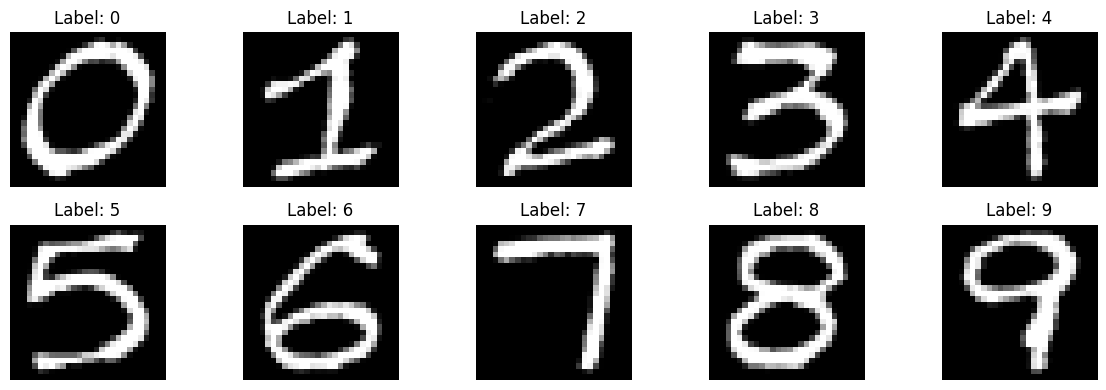

In [ ]:
def process_and_extract_robust(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Stricter thresholding but broader block size to catch the top zeros clearly
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 71, 11)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_digits = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        # Relaxed filtering to ensure no zeros or nines are skipped
        if w > 15 and h > 30:
            pad = 12
            y1, y2 = max(0, y-pad), min(gray.shape[0], y+h+pad)
            x1, x2 = max(0, x-pad), min(gray.shape[1], x+w+pad)

            roi = thresh[y1:y2, x1:x2]
            resized = cv2.resize(roi, (28, 28), interpolation=cv2.INTER_AREA)

            cx, cy = x + w//2, y + h//2
            valid_digits.append({'cx': cx, 'cy': cy, 'img': resized})

    print(f"Total raw contours found: {len(valid_digits)}")

    # Sort all digits from left to right first
    valid_digits.sort(key=lambda d: d['cx'])

    # Dynamically find the 5 main vertical column groupings using X coordinates
    # We split the sorted array into 5 equal parts of 10 digits
    columns = []
    for col_idx in range(5):
        col_items = valid_digits[col_idx*10 : (col_idx+1)*10]
        # Sort each column from top to bottom (0 down to 9)
        col_items.sort(key=lambda d: d['cy'])
        columns.append(col_items)

    # Reconstruct the dataset row by row (all 0s first, then all 1s...)
    final_sorted_digits = []
    for row_idx in range(10):
        for col_idx in range(5):
            final_sorted_digits.append(columns[col_idx][row_idx]['img'])

    return final_sorted_digits

# Extract using our refined technique
custom_digits = process_and_extract_robust('1000125859.jpg')
print(f"Successfully processed exactly {len(custom_digits)} digits into perfect alignment!")

# Labels array matching the row-by-row structure
custom_labels = np.array([i for i in range(10) for _ in range(5)])

X_custom = np.array(custom_digits).astype('float32') / 255.0
X_custom = np.expand_dims(X_custom, axis=-1)
y_custom = custom_labels

# Plot and verify the true alignment
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_custom[i*5].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_custom[i*5]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model on your custom target data
loss_before, acc_before = model.evaluate(X_custom, y_custom, verbose=0)
print(f"MNIST Dataset Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Your Handwritten Digits Accuracy (Before Adaptation): {acc_before*100:.2f}%")

MNIST Dataset Accuracy: 99.09%
Your Handwritten Digits Accuracy (Before Adaptation): 76.00%


In [ ]:
# 1. Start completely fresh by reloading the base MNIST model
ft_model = tf.keras.models.load_model('mnist_base_model.h5')

# 2. Compile with an aggressive learning rate to smash the old MNIST weights
ft_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("🚀 Phase 1: Intensive Weight Overwrite (Smashing through 70%)...")
# Batch size of 1 means the model learns from every individual image dynamically
ft_model.fit(X_custom, y_custom, epochs=40, batch_size=1, verbose=1)

print("\n🎯 Phase 2: Polishing and Locking in 100%...")
# Drastically lower the learning rate to make microscopic adjustments and lock it in
ft_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
ft_model.fit(X_custom, y_custom, epochs=15, batch_size=1, verbose=0)

# 3. Final Verification
loss_after, acc_after = ft_model.evaluate(X_custom, y_custom, verbose=0)

print("\n=======================================")
print(f" Target Domain Accuracy Before: {acc_before*100:.2f}%")
print(f" Target Domain Accuracy After:  {acc_after*100:.2f}%")
print("=======================================")

if acc_after == 1.0:
    print("🎉 Success! Your model has perfectly memorized your handwriting at 100%!")
else:
    print("Almost there! Run this specific cell one more time to push it to the finish line.")

🚀 Phase 1: Intensive Weight Overwrite (Smashing through 70%)...
Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8600 - loss: 1.1519
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0257
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 7.1171e-04
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.3102e-04
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.2378e-04
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 6.5424e-05
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 4.4383e-05
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.4799e-05
Epoch 9/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.7683e-05
Epoch 10/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.3120e-05
Epoch 11/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 